# HW3

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torch.optim as optim
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np

In [15]:
device = 'cpu'
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=125, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=125, shuffle=False)

In [16]:
def train_one_epoch(net, train_dataloader, criterion, optimizer, device):
    net.train()
    losses = []
    correct = 0
    total = 0
    
    for i, batch in enumerate(train_dataloader):
        x, labels = batch
        x = x.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        out = net(x)
        loss = criterion(out, labels)
        loss.backward()
        
        if i % 50 == 0:
            losses.append(loss.detach().cpu())
        
        optimizer.step()
        
        _, predicted = out.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if i % 200 == 0:
            print(f"Step: {i}/{len(train_dataloader)}. Loss: {loss.detach():.3f}")
    
    accuracy = 100. * correct / total
    return np.mean(losses), accuracy

def run_test(net, test_dataloader, criterion, device):
    net.eval()
    losses = []
    correct = 0
    total = 0
    
    with torch.no_grad():
        for data in tqdm(test_dataloader):
            x, labels = data
            x = x.to(device)
            labels = labels.to(device)
            
            out = net(x)
            loss = criterion(out, labels)
            losses.append(loss.detach().cpu())
            
            _, predicted = out.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    accuracy = 100. * correct / total
    return np.mean(losses), accuracy

def train_model(net, model_name, epochs=10, lr=0.05, weight_decay=0.0):
    net.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=lr, weight_decay=weight_decay)
    
    train_losses, train_accs = [], []
    val_losses, val_accs = [], []
    
    print(f"Training: {model_name}")
    
    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")
        train_loss, train_acc = train_one_epoch(net, train_dataloader, criterion, optimizer, device)
        val_loss, val_acc = run_test(net, test_dataloader, criterion, device)
        
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
        print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    
    return {'train_loss': train_losses, 'train_acc': train_accs, 
            'val_loss': val_losses, 'val_acc': val_accs}

#### Возьмите один простой набор данных (MNIST, FMNIST, CIFAR-10 и т.д.). Обучите на нём простую модель нейронной сети (не CNN!!!) с применением методов регуляризации и с функцией активации ReLU. Архитектуру задаете сами. Постройте график значения функции потерь от количества эпох, а также график метрик качества от количества эпох

In [17]:
class NetRegularized(nn.Module):
    def __init__(self, input_size=28*28, hidden1=256, hidden2=128, output_size=10):
        super(NetRegularized, self).__init__()
        self.l1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(0.3)
        
        self.l2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(0.3)
        
        self.l3 = nn.Linear(hidden2, output_size)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.dropout1(self.relu1(self.l1(x)))
        x = self.dropout2(self.relu2(self.l2(x)))
        x = self.l3(x)
        return x

net_reg = NetRegularized()
history_reg = train_model(net_reg, "ReLU + Regularization", 
                          epochs=10, lr=0.05, weight_decay=0.001)

Training: ReLU + Regularization

Epoch 1/10
Step: 0/480. Loss: 2.307
Step: 200/480. Loss: 0.903
Step: 400/480. Loss: 0.743


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.22it/s]


Train Loss: 1.1631, Train Acc: 61.88%
Val Loss: 0.6861, Val Acc: 74.88%

Epoch 2/10
Step: 0/480. Loss: 0.700
Step: 200/480. Loss: 0.837
Step: 400/480. Loss: 0.743


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 26.03it/s]


Train Loss: 0.6753, Train Acc: 77.26%
Val Loss: 0.5496, Val Acc: 80.66%

Epoch 3/10
Step: 0/480. Loss: 0.564
Step: 200/480. Loss: 0.610
Step: 400/480. Loss: 0.585


...

Train Loss: 0.4044, Train Acc: 85.30%
Val Loss: 0.4163, Val Acc: 84.85%

Epoch 9/10
Step: 0/480. Loss: 0.441
Step: 200/480. Loss: 0.383
Step: 400/480. Loss: 0.407


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.20it/s]


Train Loss: 0.4216, Train Acc: 85.50%
Val Loss: 0.4024, Val Acc: 85.72%

Epoch 10/10
Step: 0/480. Loss: 0.382
Step: 200/480. Loss: 0.380
Step: 400/480. Loss: 0.483


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.83it/s]

Train Loss: 0.4213, Train Acc: 85.92%
Val Loss: 0.3978, Val Acc: 85.45%


#### Уберите из архитектуры регуляризацию. Что стало с результатом? Постройте графики и сравните с оригинальной моделью

In [18]:
class NetNoRegularization(nn.Module):
    def __init__(self, input_size=28*28, hidden1=256, hidden2=128, output_size=10):
        super(NetNoRegularization, self).__init__()
        self.l1 = nn.Linear(input_size, hidden1)
        self.relu1 = nn.ReLU()
        
        self.l2 = nn.Linear(hidden1, hidden2)
        self.relu2 = nn.ReLU()
        
        self.l3 = nn.Linear(hidden2, output_size)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.relu1(self.l1(x))
        x = self.relu2(self.l2(x))
        x = self.l3(x)
        return x

net_no_reg = NetNoRegularization()
history_no_reg = train_model(net_no_reg, "ReLU (No Regularization)", 
                             epochs=10, lr=0.05, weight_decay=0.0)

Training: ReLU (No Regularization)

Epoch 1/10
Step: 0/480. Loss: 2.307
Step: 200/480. Loss: 1.049
Step: 400/480. Loss: 0.551


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.56it/s]


Train Loss: 1.0842, Train Acc: 66.91%
Val Loss: 0.6595, Val Acc: 75.84%

Epoch 2/10
Step: 0/480. Loss: 0.603
Step: 200/480. Loss: 0.520
Step: 400/480. Loss: 0.397


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.23it/s]


Train Loss: 0.5627, Train Acc: 80.27%
Val Loss: 0.5858, Val Acc: 78.26%

Epoch 3/10
Step: 0/480. Loss: 0.465
Step: 200/480. Loss: 0.501
Step: 400/480. Loss: 0.478


...

Train Loss: 0.3435, Train Acc: 86.67%
Val Loss: 0.4011, Val Acc: 85.82%

Epoch 9/10
Step: 0/480. Loss: 0.264
Step: 200/480. Loss: 0.399
Step: 400/480. Loss: 0.304


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.08it/s]


Train Loss: 0.3340, Train Acc: 87.00%
Val Loss: 0.4167, Val Acc: 85.10%

Epoch 10/10
Step: 0/480. Loss: 0.466
Step: 200/480. Loss: 0.453
Step: 400/480. Loss: 0.390


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.87it/s]

Train Loss: 0.3736, Train Acc: 87.28%
Val Loss: 0.3940, Val Acc: 85.98%


#### Замените ReLU на сигмоиду. Что стало с результатом? Если он ухудшился, то почему? Постройте графики и сравните с оригинальной моделью

In [19]:
class NetSigmoid(nn.Module):
    def __init__(self, input_size=28*28, hidden1=256, hidden2=128, output_size=10):
        super(NetSigmoid, self).__init__()
        self.l1 = nn.Linear(input_size, hidden1)
        self.sigmoid1 = nn.Sigmoid()
        
        self.l2 = nn.Linear(hidden1, hidden2)
        self.sigmoid2 = nn.Sigmoid()
        
        self.l3 = nn.Linear(hidden2, output_size)
    
    def forward(self, x):
        x = x.flatten(start_dim=1)
        x = self.sigmoid1(self.l1(x))
        x = self.sigmoid2(self.l2(x))
        x = self.l3(x)
        return x

net_sigm = NetSigmoid()
history_sigm = train_model(net_sigm, "Sigmoid (No Regularization)", 
                           epochs=10, lr=0.05, weight_decay=0.0)

Training: Sigmoid (No Regularization)

Epoch 1/10
Step: 0/480. Loss: 2.367
Step: 200/480. Loss: 2.280
Step: 400/480. Loss: 2.241


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.31it/s]


Train Loss: 2.2772, Train Acc: 16.55%
Val Loss: 2.1788, Val Acc: 32.71%

Epoch 2/10
Step: 0/480. Loss: 2.180
Step: 200/480. Loss: 1.849
Step: 400/480. Loss: 1.458


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 26.22it/s]


Train Loss: 1.7898, Train Acc: 42.81%
Val Loss: 1.4047, Val Acc: 53.59%

Epoch 3/10
Step: 0/480. Loss: 1.448
Step: 200/480. Loss: 1.246
Step: 400/480. Loss: 1.100


...

Train Loss: 0.6905, Train Acc: 73.95%
Val Loss: 0.7024, Val Acc: 74.12%

Epoch 9/10
Step: 0/480. Loss: 0.654
Step: 200/480. Loss: 0.696
Step: 400/480. Loss: 0.623


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 25.40it/s]


Train Loss: 0.6453, Train Acc: 75.18%
Val Loss: 0.6675, Val Acc: 74.93%

Epoch 10/10
Step: 0/480. Loss: 0.690
Step: 200/480. Loss: 0.729
Step: 400/480. Loss: 0.636


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:03<00:00, 24.83it/s]

Train Loss: 0.6992, Train Acc: 76.00%
Val Loss: 0.6409, Val Acc: 76.19%


#### Обучите простую CNN на выбранном датасете. Визуализируйте активации на первых слоях сети. Какие закономерности находит модель?


In [20]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3)
        self.relu1 = nn.ReLU()
        self.pool1 = nn.MaxPool2d(2, 2)
        
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3)
        self.relu2 = nn.ReLU()
        
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(64 * 11 * 11, 64)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(64, 10)
    
    def forward(self, x):
        x = self.pool1(self.relu1(self.conv1(x)))
        x = self.relu2(self.conv2(x))
        x = self.flatten(x)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

net_cnn = SimpleCNN()
history_cnn = train_model(net_cnn, "CNN", epochs=5, lr=0.05, weight_decay=0.0)

Training: CNN

Epoch 1/5
Step: 0/480. Loss: 2.311
Step: 200/480. Loss: 0.729
Step: 400/480. Loss: 0.560


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 17.39it/s]


Train Loss: 0.9249, Train Acc: 69.55%
Val Loss: 0.6144, Val Acc: 75.67%

Epoch 2/5
Step: 0/480. Loss: 0.511
Step: 200/480. Loss: 0.583
Step: 400/480. Loss: 0.355


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 16.38it/s]


Train Loss: 0.5108, Train Acc: 80.96%
Val Loss: 0.4685, Val Acc: 82.97%

Epoch 3/5
Step: 0/480. Loss: 0.465
Step: 200/480. Loss: 0.438
Step: 400/480. Loss: 0.433


...

Train Loss: 0.4495, Train Acc: 84.30%
Val Loss: 0.4251, Val Acc: 84.74%

Epoch 4/5
Step: 0/480. Loss: 0.476
Step: 200/480. Loss: 0.526
Step: 400/480. Loss: 0.298


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 16.32it/s]


Train Loss: 0.3963, Train Acc: 86.09%
Val Loss: 0.4021, Val Acc: 85.16%

Epoch 5/5
Step: 0/480. Loss: 0.310
Step: 200/480. Loss: 0.298
Step: 400/480. Loss: 0.323


100%|██████████████████████████████████████████████████████████████████████████████████| 80/80 [00:04<00:00, 16.55it/s]

Train Loss: 0.3395, Train Acc: 87.13%
Val Loss: 0.3532, Val Acc: 87.34%


*Графики*

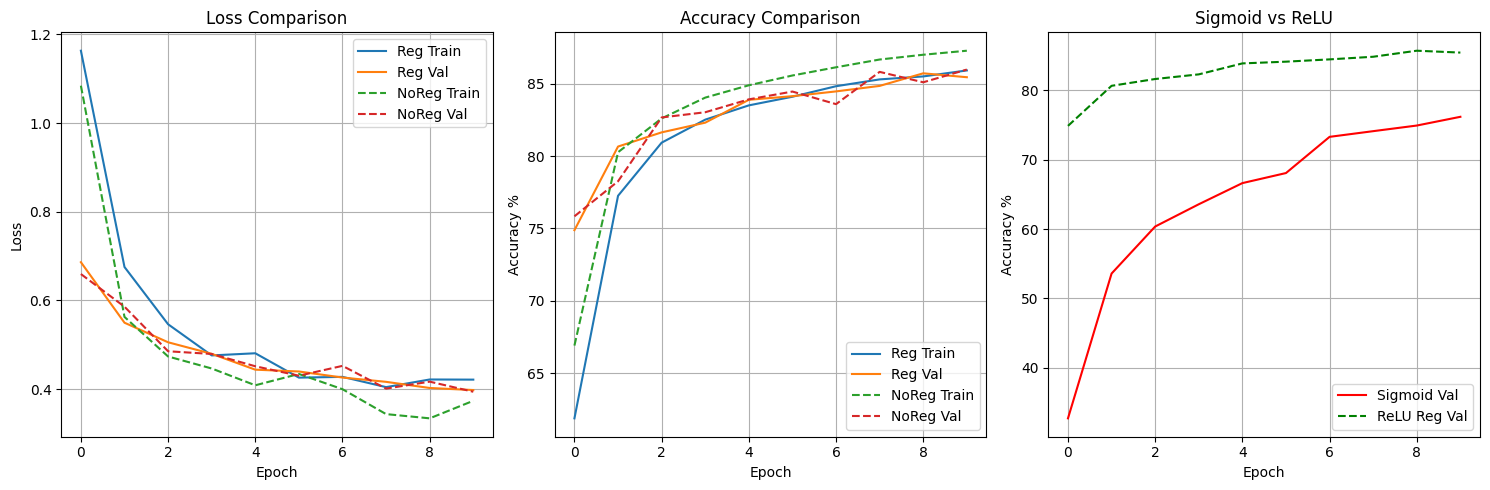

In [21]:
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.plot(history_reg['train_loss'], label='Reg Train')
plt.plot(history_reg['val_loss'], label='Reg Val')
plt.plot(history_no_reg['train_loss'], '--', label='NoReg Train')
plt.plot(history_no_reg['val_loss'], '--', label='NoReg Val')
plt.title('Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 2)
plt.plot(history_reg['train_acc'], label='Reg Train')
plt.plot(history_reg['val_acc'], label='Reg Val')
plt.plot(history_no_reg['train_acc'], '--', label='NoReg Train')
plt.plot(history_no_reg['val_acc'], '--', label='NoReg Val')
plt.title('Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(True)

plt.subplot(1, 3, 3)
plt.plot(history_sigm['val_acc'], label='Sigmoid Val', color='red')
plt.plot(history_reg['val_acc'], label='ReLU Reg Val', color='green', linestyle='--')
plt.title('Sigmoid vs ReLU')
plt.xlabel('Epoch')
plt.ylabel('Accuracy %')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

*Визуализация активаций на первых слоях сети для CNN*

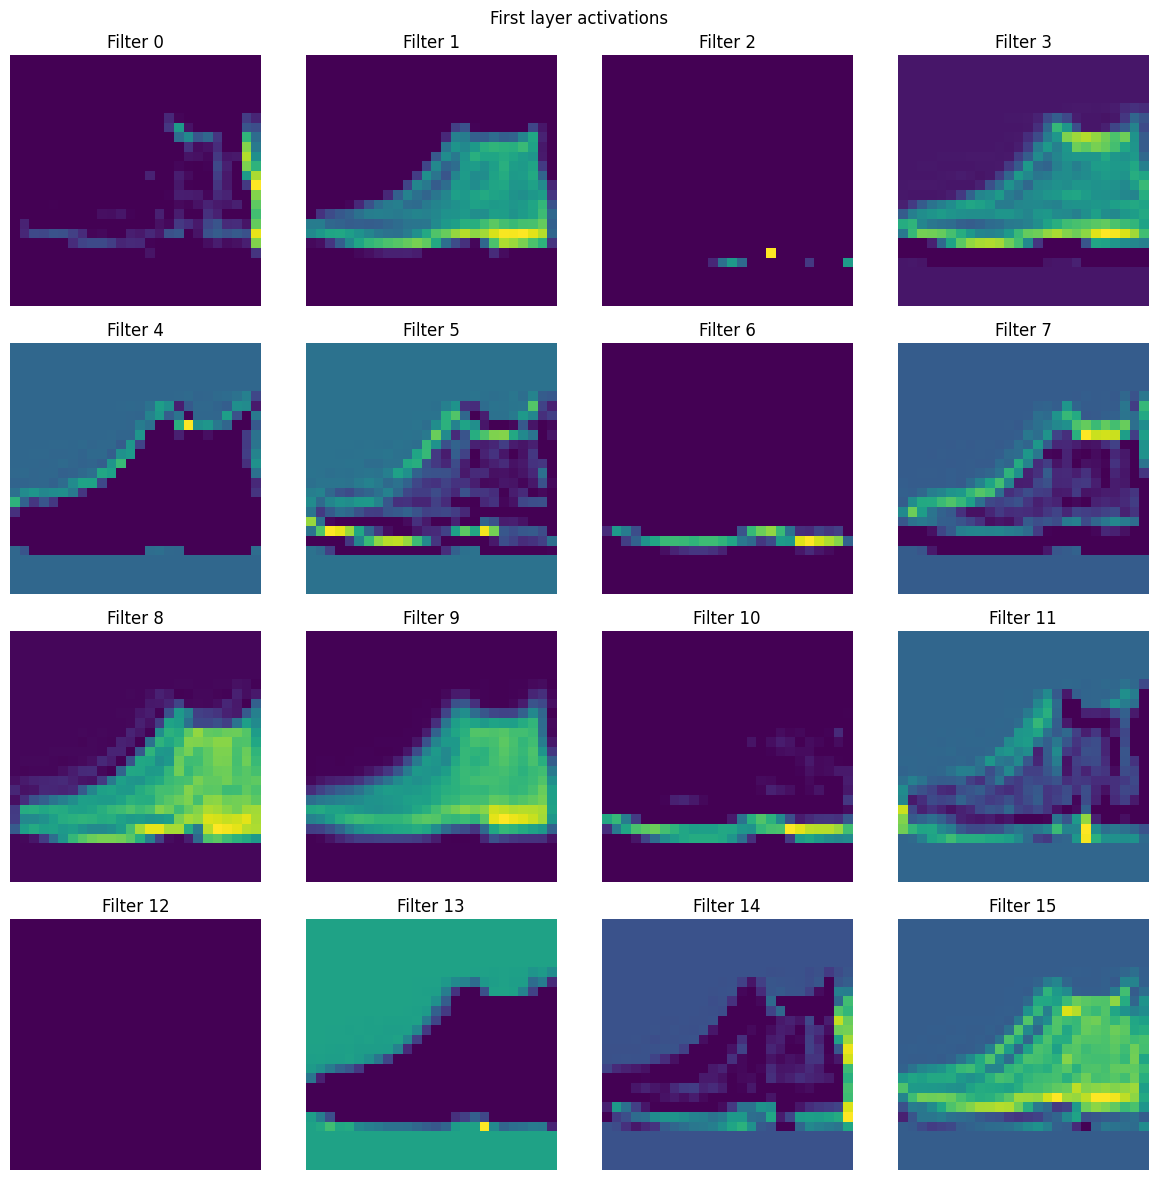

In [22]:
net_cnn.eval()
imgs, labels = next(iter(test_dataloader))
img = imgs[0].unsqueeze(0).to(device)

with torch.no_grad():
    conv1_out = net_cnn.relu1(net_cnn.conv1(img))

activations = conv1_out.cpu().numpy()[0]

plt.figure(figsize=(12, 12))
for i in range(min(16, activations.shape[0])):
    plt.subplot(4, 4, i+1)
    plt.imshow(activations[i], cmap='viridis')
    plt.axis('off')
    plt.title(f"Filter {i}")
plt.suptitle("First layer activations")
plt.tight_layout()
plt.show()

*Ответы на вопросы*

1. Что стало с результатом без регуляризации?
   - Увеличился разрыв между train и validation accuracy  
2. Почему Sigmoid хуже ReLU?
   - Проблема затухающего градиента
   - У sigmoid дольше сходимость
   - Sigmoid вычислительно сложнее (exp)  
3. Какие закономерности находит CNN?
   - На первых слоях: простые границы, углы, контуры
   - Вертикальные и горизонтальные линии